In [ ]:
from google.colab import files
files.upload()  # Select your kaggle.json from Downloads folder

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hps1745","key":"04cd262807eab14fdb377e615555b59c"}'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle setup done!")

✅ Kaggle setup done!


In [ ]:
!kaggle datasets download -d rohitrox/healthcare-provider-fraud-detection-analysis
print("✅ Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/rohitrox/healthcare-provider-fraud-detection-analysis
License(s): CC0-1.0
100% 25.4M/25.4M [00:00<00:00, 88.1MB/s]

✅ Dataset downloaded!


In [ ]:
!unzip healthcare-provider-fraud-detection-analysis.zip -d healthcare_fraud
print("✅ Unzipped successfully!")

Archive:  healthcare-provider-fraud-detection-analysis.zip
  inflating: healthcare_fraud/Test-1542969243754.csv  
  inflating: healthcare_fraud/Test_Beneficiarydata-1542969243754.csv  
  inflating: healthcare_fraud/Test_Inpatientdata-1542969243754.csv  
  inflating: healthcare_fraud/Test_Outpatientdata-1542969243754.csv  
  inflating: healthcare_fraud/Train-1542865627584.csv  
  inflating: healthcare_fraud/Train_Beneficiarydata-1542865627584.csv  
  inflating: healthcare_fraud/Train_Inpatientdata-1542865627584.csv  
  inflating: healthcare_fraud/Train_Outpatientdata-1542865627584.csv  
✅ Unzipped successfully!


In [ ]:
import os
files_list = os.listdir('healthcare_fraud')
for f in files_list:
    print(f)

Train_Outpatientdata-1542865627584.csv
Train_Inpatientdata-1542865627584.csv
Test-1542969243754.csv
Test_Outpatientdata-1542969243754.csv
Test_Inpatientdata-1542969243754.csv
Train_Beneficiarydata-1542865627584.csv
Train-1542865627584.csv
Test_Beneficiarydata-1542969243754.csv


In [ ]:
!pip install imbalanced-learn xgboost -q
print("✅ Libraries ready!")

✅ Libraries ready!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
labels      = pd.read_csv('healthcare_fraud/Train-1542865627584.csv')
beneficiary = pd.read_csv('healthcare_fraud/Train_Beneficiarydata-1542865627584.csv')
inpatient   = pd.read_csv('healthcare_fraud/Train_Inpatientdata-1542865627584.csv')
outpatient  = pd.read_csv('healthcare_fraud/Train_Outpatientdata-1542865627584.csv')

print("✅ Labels Shape     :", labels.shape)
print("✅ Beneficiary Shape:", beneficiary.shape)
print("✅ Inpatient Shape  :", inpatient.shape)
print("✅ Outpatient Shape :", outpatient.shape)

✅ Labels Shape     : (5410, 2)
✅ Beneficiary Shape: (138556, 25)
✅ Inpatient Shape  : (40474, 30)
✅ Outpatient Shape : (517737, 27)


PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64


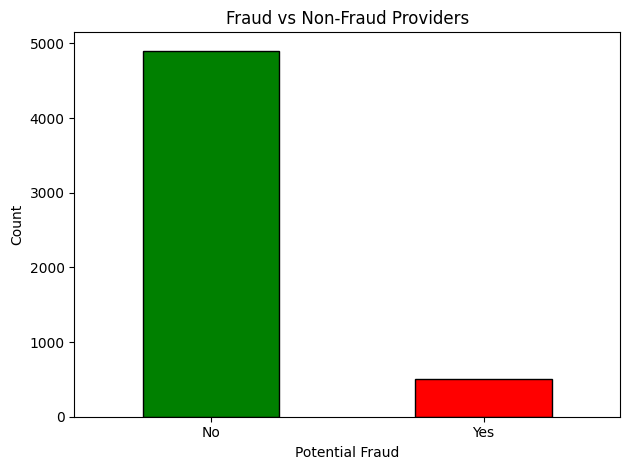

In [ ]:
print(labels['PotentialFraud'].value_counts())

labels['PotentialFraud'].value_counts().plot(
    kind='bar',
    color=['green', 'red'],
    title='Fraud vs Non-Fraud Providers',
    edgecolor='black'
)
plt.xlabel('Potential Fraud')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
print("=== LABELS ===")
print(labels.head())

print("\n=== BENEFICIARY ===")
print(beneficiary.head())

print("\n=== INPATIENT ===")
print(inpatient.head())

print("\n=== OUTPATIENT ===")
print(outpatient.head())

=== LABELS ===
   Provider PotentialFraud
0  PRV51001             No
1  PRV51003            Yes
2  PRV51004             No
3  PRV51005            Yes
4  PRV51007             No

=== BENEFICIARY ===
      BeneID         DOB  DOD  Gender  Race RenalDiseaseIndicator  State  \
0  BENE11001  1943-01-01  NaN       1     1                     0     39   
1  BENE11002  1936-09-01  NaN       2     1                     0     39   
2  BENE11003  1936-08-01  NaN       1     1                     0     52   
3  BENE11004  1922-07-01  NaN       1     1                     0     39   
4  BENE11005  1935-09-01  NaN       1     1                     0     24   

   County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ...  \
0     230                   12                   12  ...   
1     280                   12                   12  ...   
2     590                   12                   12  ...   
3     270                   12                   12  ...   
4     680                   12               

In [ ]:
print("=== LABELS INFO ===")
print(labels.info())

print("\n=== BENEFICIARY INFO ===")
print(beneficiary.info())

print("\n=== INPATIENT INFO ===")
print(inpatient.info())

print("\n=== OUTPATIENT INFO ===")
print(outpatient.info())

=== LABELS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5410 entries, 0 to 5409
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Provider        5410 non-null   object
 1   PotentialFraud  5410 non-null   object
dtypes: object(2)
memory usage: 84.7+ KB
None

=== BENEFICIARY INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138556 entries, 0 to 138555
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   BeneID                           138556 non-null  object
 1   DOB                              138556 non-null  object
 2   DOD                              1421 non-null    object
 3   Gender                           138556 non-null  int64 
 4   Race                             138556 non-null  int64 
 5   RenalDiseaseIndicator            138556 non-null  object
 6   State         

In [ ]:
print("=== Missing Values ===\n")

print("Labels:")
print(labels.isnull().sum(), "\n")

print("Beneficiary:")
print(beneficiary.isnull().sum(), "\n")

print("Inpatient:")
print(inpatient.isnull().sum(), "\n")

print("Outpatient:")
print(outpatient.isnull().sum(), "\n")

=== Missing Values ===

Labels:
Provider          0
PotentialFraud    0
dtype: int64 

Beneficiary:
BeneID                                  0
DOB                                     0
DOD                                137135
Gender                                  0
Race                                    0
RenalDiseaseIndicator                   0
State                                   0
County                                  0
NoOfMonths_PartACov                     0
NoOfMonths_PartBCov                     0
ChronicCond_Alzheimer                   0
ChronicCond_Heartfailure                0
ChronicCond_KidneyDisease               0
ChronicCond_Cancer                      0
ChronicCond_ObstrPulmonary              0
ChronicCond_Depression                  0
ChronicCond_Diabetes                    0
ChronicCond_IschemicHeart               0
ChronicCond_Osteoporasis                0
ChronicCond_rheumatoidarthritis         0
ChronicCond_stroke                      0
IPAnnualReimbursem

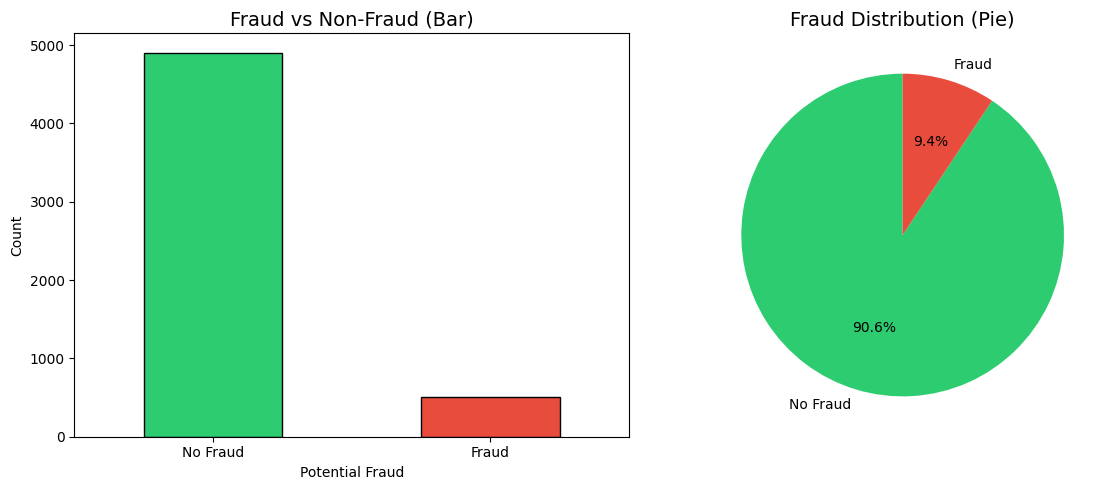

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
labels['PotentialFraud'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black'
)
axes[0].set_title('Fraud vs Non-Fraud (Bar)', fontsize=14)
axes[0].set_xlabel('Potential Fraud')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Fraud', 'Fraud'], rotation=0)

# Pie Chart
labels['PotentialFraud'].value_counts().plot(
    kind='pie', ax=axes[1],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    labels=['No Fraud', 'Fraud'],
    startangle=90
)
axes[1].set_title('Fraud Distribution (Pie)', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

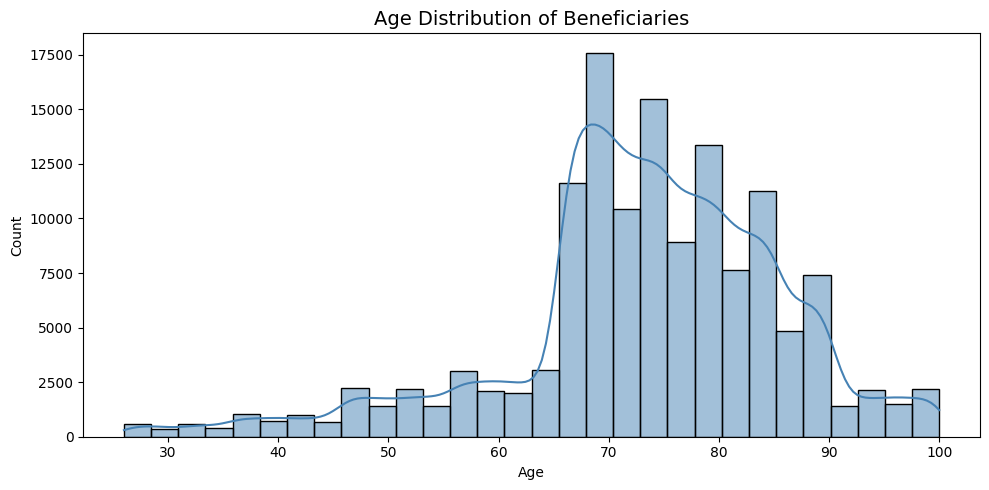

Average Age: 73.1
Min Age: 26
Max Age: 100


In [ ]:
# Calculate Age from DOB
beneficiary['DOB'] = pd.to_datetime(beneficiary['DOB'], errors='coerce')
beneficiary['Age'] = 2009 - beneficiary['DOB'].dt.year  # Dataset is from 2009

plt.figure(figsize=(10, 5))
sns.histplot(beneficiary['Age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Beneficiaries', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Average Age:", round(beneficiary['Age'].mean(), 1))
print("Min Age:", beneficiary['Age'].min())
print("Max Age:", beneficiary['Age'].max())

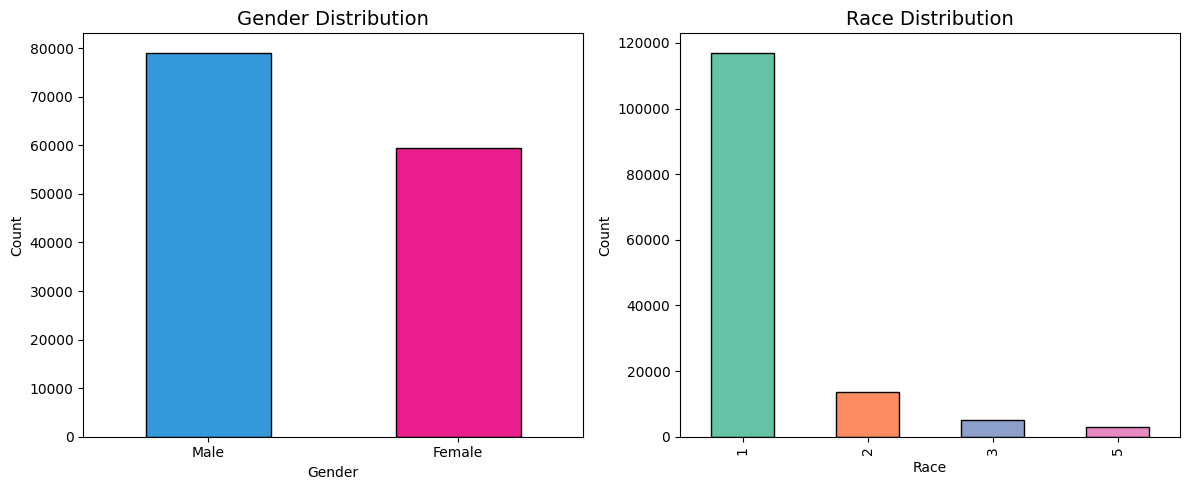

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender
beneficiary['Gender'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#3498db', '#e91e8c'],
    edgecolor='black'
)
axes[0].set_title('Gender Distribution', fontsize=14)
axes[0].set_xticklabels(['Male', 'Female'], rotation=0)
axes[0].set_ylabel('Count')

# Race
beneficiary['Race'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=sns.color_palette('Set2'),
    edgecolor='black'
)
axes[1].set_title('Race Distribution', fontsize=14)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

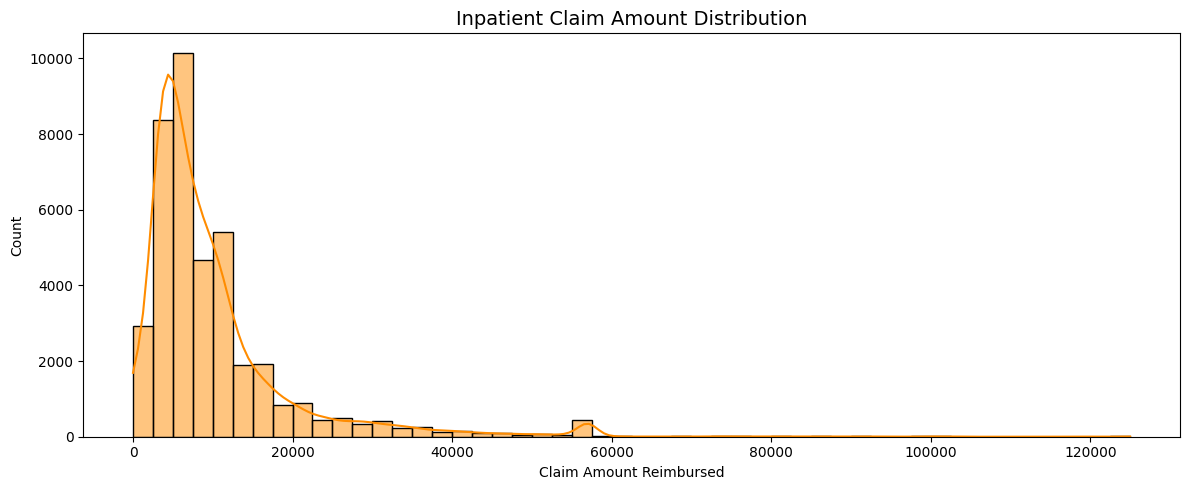

Average Inpatient Claim: 10087.88
Max Claim: 125000
Min Claim: 0


In [ ]:
plt.figure(figsize=(12, 5))

# Distribution of Claim Amounts
sns.histplot(inpatient['InscClaimAmtReimbursed'], bins=50,
             kde=True, color='darkorange')
plt.title('Inpatient Claim Amount Distribution', fontsize=14)
plt.xlabel('Claim Amount Reimbursed')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Average Inpatient Claim:", round(inpatient['InscClaimAmtReimbursed'].mean(), 2))
print("Max Claim:", inpatient['InscClaimAmtReimbursed'].max())
print("Min Claim:", inpatient['InscClaimAmtReimbursed'].min())

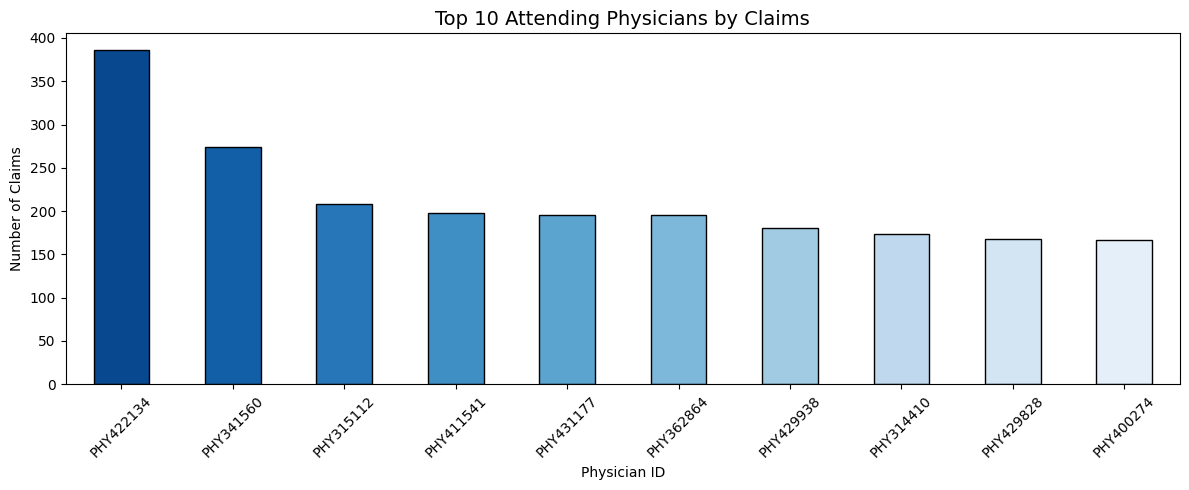

In [ ]:
plt.figure(figsize=(12, 5))

inpatient['AttendingPhysician'].value_counts().head(10).plot(
    kind='bar',
    color=sns.color_palette('Blues_r', 10),
    edgecolor='black'
)
plt.title('Top 10 Attending Physicians by Claims', fontsize=14)
plt.xlabel('Physician ID')
plt.ylabel('Number of Claims')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
chronic_cols = [
    'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
    'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
    'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidArtritis',
    'ChronicCond_stroke'
]

chronic_counts = (beneficiary[chronic_cols] == 1).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
chronic_counts.plot(kind='bar', color=sns.color_palette('Reds_r', 11), edgecolor='black')
plt.title('Chronic Conditions Prevalence Among Beneficiaries', fontsize=14)
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

KeyError: "['ChronicCond_rheumatoidArtritis'] not in index"

In [ ]:
# Check exact chronic condition column names
chronic_actual = [col for col in beneficiary.columns if 'Chronic' in col]
print("Actual Chronic Columns in Dataset:")
for col in chronic_actual:
    print(col)

Actual Chronic Columns in Dataset:
ChronicCond_Alzheimer
ChronicCond_Heartfailure
ChronicCond_KidneyDisease
ChronicCond_Cancer
ChronicCond_ObstrPulmonary
ChronicCond_Depression
ChronicCond_Diabetes
ChronicCond_IschemicHeart
ChronicCond_Osteoporasis
ChronicCond_rheumatoidarthritis
ChronicCond_stroke


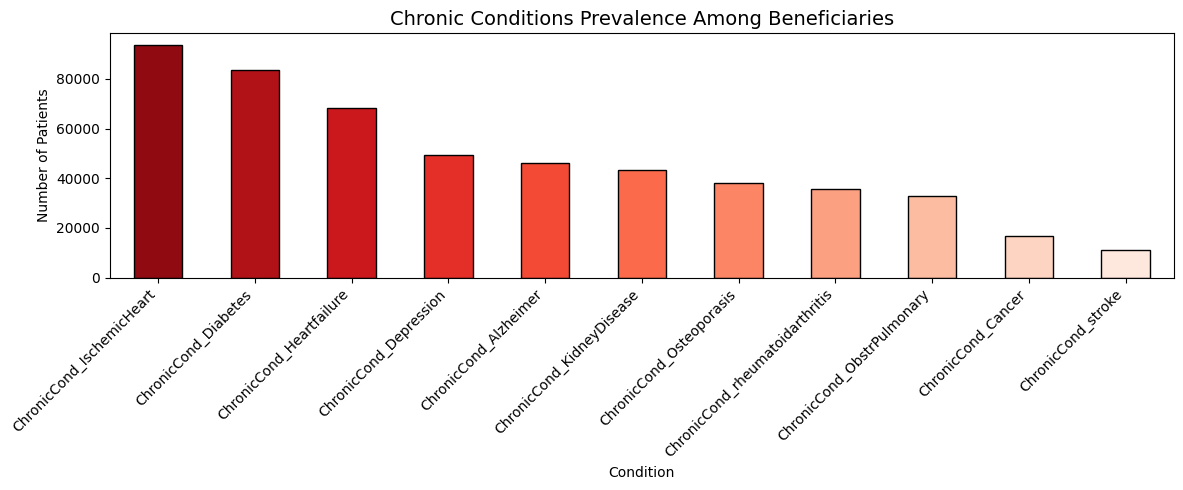

In [ ]:
chronic_cols = [
    'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
    'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
    'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',  # ✅ Fixed here
    'ChronicCond_stroke'
]

chronic_counts = (beneficiary[chronic_cols] == 1).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
chronic_counts.plot(kind='bar', color=sns.color_palette('Reds_r', 11), edgecolor='black')
plt.title('Chronic Conditions Prevalence Among Beneficiaries', fontsize=14)
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print("=== INPATIENT SUMMARY ===")
print(inpatient[['InscClaimAmtReimbursed', 'DeductibleAmtPaid', 'IPAnnualReimbursementAmt']].describe())

print("\n=== OUTPATIENT SUMMARY ===")
print(outpatient[['InscClaimAmtReimbursed', 'DeductibleAmtPaid']].describe())

=== INPATIENT SUMMARY ===


KeyError: "['IPAnnualReimbursementAmt'] not in index"

In [ ]:
print("=== INPATIENT COLUMNS ===")
print(inpatient.columns.tolist())

print("\n=== OUTPATIENT COLUMNS ===")
print(outpatient.columns.tolist())

=== INPATIENT COLUMNS ===
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode', 'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6']

=== OUTPATIENT COLUMNS ===
['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider', 'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician', 'OtherPhysician', 'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3', 'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCo

In [ ]:
print("=== INPATIENT SUMMARY ===")
print(inpatient[['InscClaimAmtReimbursed', 'DeductibleAmtPaid']].describe())

print("\n=== OUTPATIENT SUMMARY ===")
print(outpatient[['InscClaimAmtReimbursed', 'DeductibleAmtPaid']].describe())

=== INPATIENT SUMMARY ===
       InscClaimAmtReimbursed  DeductibleAmtPaid
count            40474.000000            39575.0
mean             10087.884074             1068.0
std              10303.099402                0.0
min                  0.000000             1068.0
25%               4000.000000             1068.0
50%               7000.000000             1068.0
75%              12000.000000             1068.0
max             125000.000000             1068.0

=== OUTPATIENT SUMMARY ===
       InscClaimAmtReimbursed  DeductibleAmtPaid
count           517737.000000      517737.000000
mean               286.334799           2.779233
std                694.034343          15.785839
min                  0.000000           0.000000
25%                 40.000000           0.000000
50%                 80.000000           0.000000
75%                200.000000           0.000000
max             102500.000000         897.000000


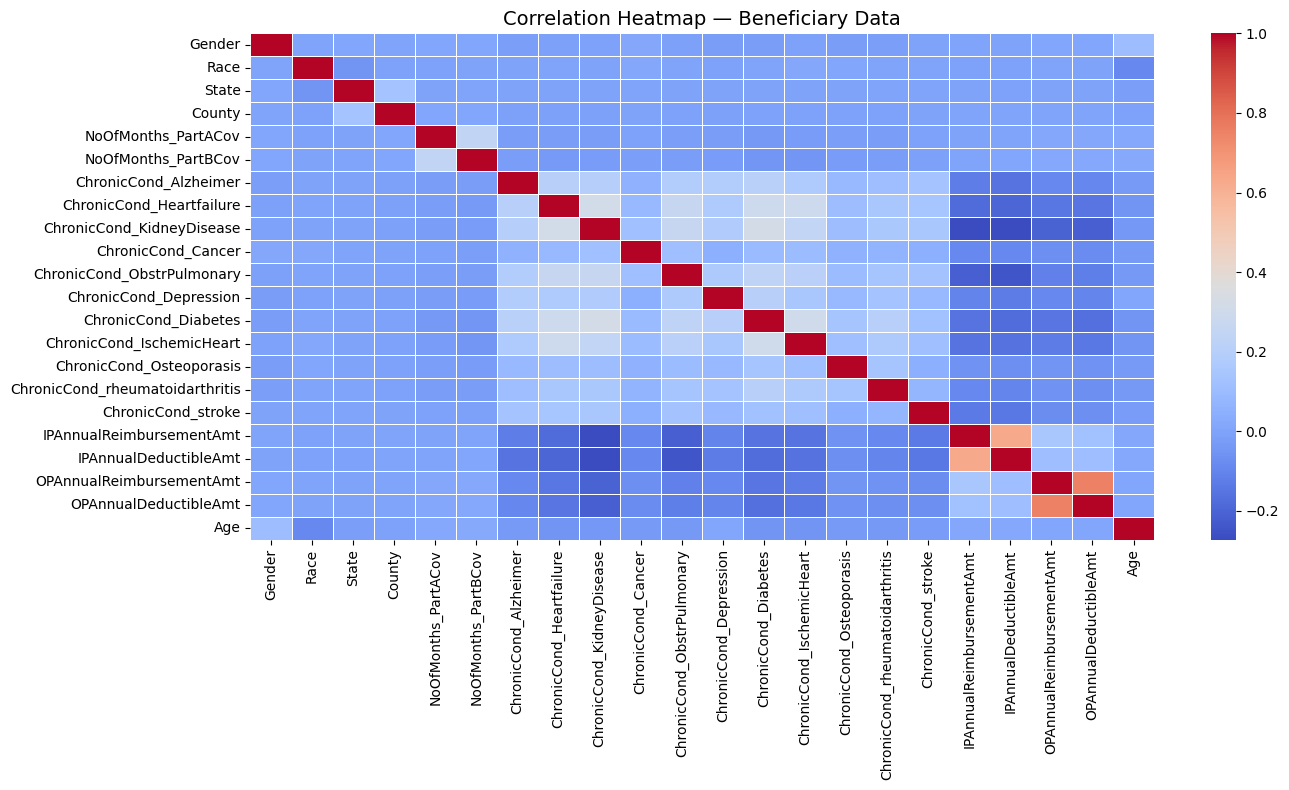

In [ ]:
plt.figure(figsize=(14, 8))

numeric_cols = beneficiary.select_dtypes(include=np.number).columns.tolist()
corr = beneficiary[numeric_cols].corr()

sns.heatmap(corr, annot=False, cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Heatmap — Beneficiary Data', fontsize=14)
plt.tight_layout()
plt.show()

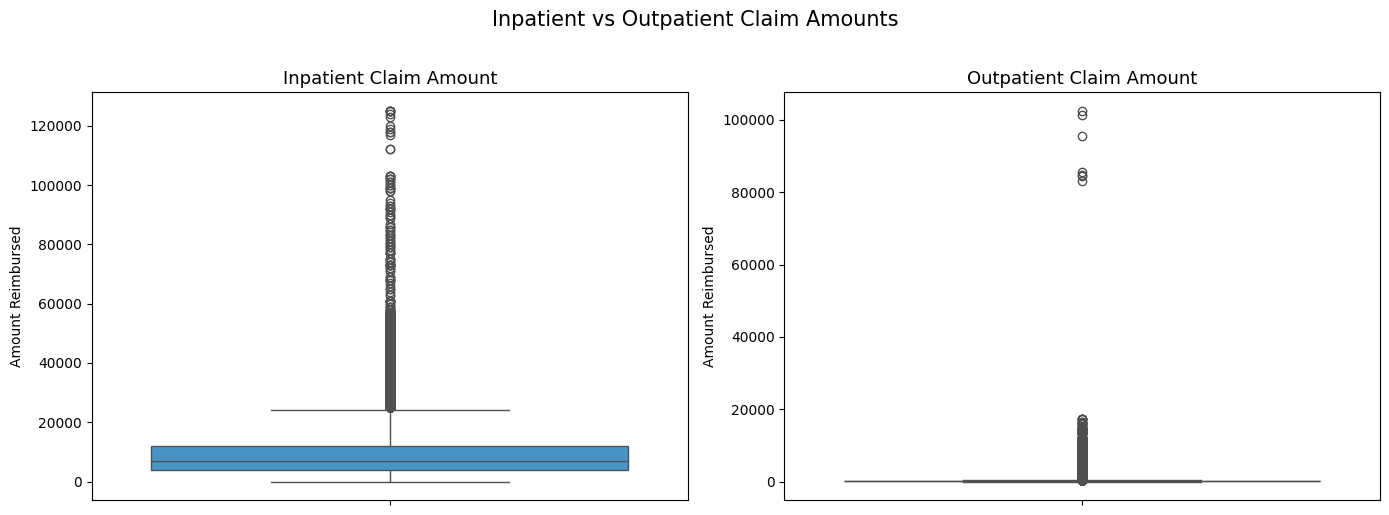

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=inpatient['InscClaimAmtReimbursed'], ax=axes[0], color='#3498db')
axes[0].set_title('Inpatient Claim Amount', fontsize=13)
axes[0].set_ylabel('Amount Reimbursed')

sns.boxplot(y=outpatient['InscClaimAmtReimbursed'], ax=axes[1], color='#e67e22')
axes[1].set_title('Outpatient Claim Amount', fontsize=13)
axes[1].set_ylabel('Amount Reimbursed')

plt.suptitle('Inpatient vs Outpatient Claim Amounts', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

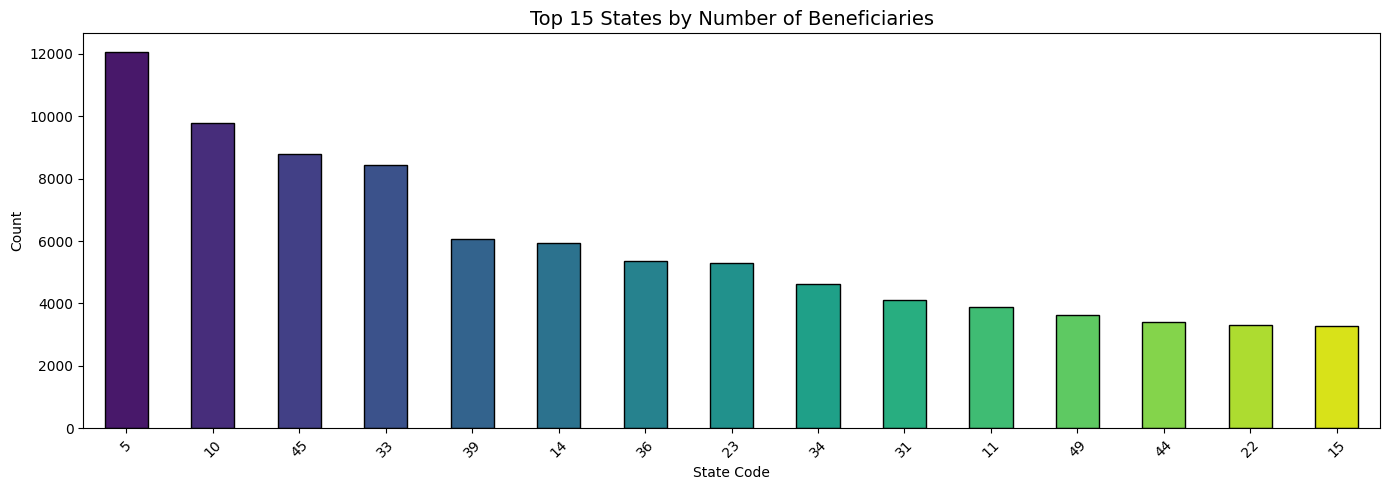

In [ ]:
plt.figure(figsize=(14, 5))

beneficiary['State'].value_counts().head(15).plot(
    kind='bar',
    color=sns.color_palette('viridis', 15),
    edgecolor='black'
)
plt.title('Top 15 States by Number of Beneficiaries', fontsize=14)
plt.xlabel('State Code')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 50)
print("        EDA SUMMARY — KEY INSIGHTS")
print("=" * 50)

fraud_pct = round(labels['PotentialFraud'].value_counts(normalize=True)['Yes'] * 100, 2)
print(f"\n🔴 Fraud Providers     : {(labels['PotentialFraud'] == 'Yes').sum()}")
print(f"🟢 Non-Fraud Providers : {(labels['PotentialFraud'] == 'No').sum()}")
print(f"⚠️  Fraud Percentage    : {fraud_pct}%")

print(f"\n👥 Total Beneficiaries      : {beneficiary.shape[0]}")
print(f"🏥 Total Inpatient Claims   : {inpatient.shape[0]}")
print(f"🏨 Total Outpatient Claims  : {outpatient.shape[0]}")

print(f"\n💰 Avg Inpatient Claim  : ${round(inpatient['InscClaimAmtReimbursed'].mean(), 2)}")
print(f"💰 Avg Outpatient Claim : ${round(outpatient['InscClaimAmtReimbursed'].mean(), 2)}")

print(f"\n👴 Average Patient Age  : {round(beneficiary['Age'].mean(), 1)} years")

print("\n✅ EDA Complete! Ready for Phase 3 — Preprocessing")
print("=" * 50)

        EDA SUMMARY — KEY INSIGHTS

🔴 Fraud Providers     : 506
🟢 Non-Fraud Providers : 4904
⚠️  Fraud Percentage    : 9.35%

👥 Total Beneficiaries      : 138556
🏥 Total Inpatient Claims   : 40474
🏨 Total Outpatient Claims  : 517737

💰 Avg Inpatient Claim  : $10087.88
💰 Avg Outpatient Claim : $286.33

👴 Average Patient Age  : 73.1 years

✅ EDA Complete! Ready for Phase 3 — Preprocessing


In [ ]:
# Add a flag to identify claim type
inpatient['ClaimType'] = 1   # 1 = Inpatient
outpatient['ClaimType'] = 0  # 0 = Outpatient

# Merge both claims
all_claims = pd.concat([inpatient, outpatient], ignore_index=True)

print("✅ Combined Claims Shape:", all_claims.shape)
print(all_claims['ClaimType'].value_counts())

✅ Combined Claims Shape: (558211, 31)
ClaimType
0    517737
1     40474
Name: count, dtype: int64


In [ ]:
# For each provider, calculate aggregate stats
provider_claims = all_claims.groupby('Provider').agg(
    Total_Claims        = ('ClaimID', 'count'),
    Total_Reimbursed    = ('InscClaimAmtReimbursed', 'sum'),
    Avg_Reimbursed      = ('InscClaimAmtReimbursed', 'mean'),
    Max_Reimbursed      = ('InscClaimAmtReimbursed', 'max'),
    Total_Deductible    = ('DeductibleAmtPaid', 'sum'),
    Avg_Deductible      = ('DeductibleAmtPaid', 'mean'),
    Unique_Patients     = ('BeneID', 'nunique'),
    Inpatient_Claims    = ('ClaimType', 'sum'),
    Unique_Physicians   = ('AttendingPhysician', 'nunique'),
).reset_index()

print("✅ Provider Level Data Shape:", provider_claims.shape)
print(provider_claims.head())

✅ Provider Level Data Shape: (5410, 10)
   Provider  Total_Claims  Total_Reimbursed  Avg_Reimbursed  Max_Reimbursed  \
0  PRV51001            25            104640     4185.600000           42000   
1  PRV51003           132            605670     4588.409091           57000   
2  PRV51004           149             52170      350.134228            3300   
3  PRV51005          1165            280910      241.124464            4080   
4  PRV51007            72             33710      468.194444           10000   

   Total_Deductible  Avg_Deductible  Unique_Patients  Inpatient_Claims  \
0            5340.0      213.600000               24                 5   
1           66286.0      502.166667              117                62   
2             310.0        2.080537              138                 0   
3            3700.0        3.175966              495                 0   
4            3264.0       45.333333               58                 3   

   Unique_Physicians  
0                

In [ ]:
# Merge claims with beneficiary info
claims_bene = all_claims.merge(beneficiary, on='BeneID', how='left')

# Aggregate beneficiary features per provider
provider_bene = claims_bene.groupby('Provider').agg(
    Avg_Age                     = ('Age', 'mean'),
    Avg_InscClaimAmtReimbursed  = ('InscClaimAmtReimbursed', 'mean'),
    Total_Alzheimer             = ('ChronicCond_Alzheimer', 'sum'),
    Total_Heartfailure          = ('ChronicCond_Heartfailure', 'sum'),
    Total_KidneyDisease         = ('ChronicCond_KidneyDisease', 'sum'),
    Total_Cancer                = ('ChronicCond_Cancer', 'sum'),
    Total_Diabetes              = ('ChronicCond_Diabetes', 'sum'),
    Total_Depression            = ('ChronicCond_Depression', 'sum'),
    Total_stroke                = ('ChronicCond_stroke', 'sum'),
).reset_index()

print("✅ Provider Beneficiary Shape:", provider_bene.shape)
print(provider_bene.head())

✅ Provider Beneficiary Shape: (5410, 10)
   Provider    Avg_Age  Avg_InscClaimAmtReimbursed  Total_Alzheimer  \
0  PRV51001  78.280000                 4185.600000               35   
1  PRV51003  69.553030                 4588.409091              208   
2  PRV51004  71.812081                  350.134228              234   
3  PRV51005  70.000858                  241.124464             1904   
4  PRV51007  68.791667                  468.194444              118   

   Total_Heartfailure  Total_KidneyDisease  Total_Cancer  Total_Diabetes  \
0                  31                   33            45              29   
1                 184                  200           254             164   
2                 210                  248           282             193   
3                1650                 1823          2165            1531   
4                 104                  122           132              95   

   Total_Depression  Total_stroke  
0                41            44  
1  

In [ ]:
# Merge provider claims + beneficiary features
provider_df = provider_claims.merge(provider_bene, on='Provider', how='left')

print("✅ Final Provider DataFrame Shape:", provider_df.shape)
print(provider_df.head())

✅ Final Provider DataFrame Shape: (5410, 19)
   Provider  Total_Claims  Total_Reimbursed  Avg_Reimbursed  Max_Reimbursed  \
0  PRV51001            25            104640     4185.600000           42000   
1  PRV51003           132            605670     4588.409091           57000   
2  PRV51004           149             52170      350.134228            3300   
3  PRV51005          1165            280910      241.124464            4080   
4  PRV51007            72             33710      468.194444           10000   

   Total_Deductible  Avg_Deductible  Unique_Patients  Inpatient_Claims  \
0            5340.0      213.600000               24                 5   
1           66286.0      502.166667              117                62   
2             310.0        2.080537              138                 0   
3            3700.0        3.175966              495                 0   
4            3264.0       45.333333               58                 3   

   Unique_Physicians    Avg_Age  Av

In [ ]:
# Merge with fraud labels
provider_df = provider_df.merge(labels, on='Provider', how='left')

# Encode fraud label: Yes=1, No=0
provider_df['Fraud'] = (provider_df['PotentialFraud'] == 'Yes').astype(int)
provider_df.drop('PotentialFraud', axis=1, inplace=True)

print("✅ Final Dataset Shape:", provider_df.shape)
print("\nFraud Distribution:")
print(provider_df['Fraud'].value_counts())

✅ Final Dataset Shape: (5410, 20)

Fraud Distribution:
Fraud
0    4904
1     506
Name: count, dtype: int64


In [ ]:
# Check missing values
print("Missing values before:\n", provider_df.isnull().sum())

# Fill missing numeric values with median
numeric_cols = provider_df.select_dtypes(include=np.number).columns
provider_df[numeric_cols] = provider_df[numeric_cols].fillna(provider_df[numeric_cols].median())

print("\n✅ Missing values after:")
print(provider_df.isnull().sum().sum(), "missing values remaining")

Missing values before:
 Provider                      0
Total_Claims                  0
Total_Reimbursed              0
Avg_Reimbursed                0
Max_Reimbursed                0
Total_Deductible              0
Avg_Deductible                1
Unique_Patients               0
Inpatient_Claims              0
Unique_Physicians             0
Avg_Age                       0
Avg_InscClaimAmtReimbursed    0
Total_Alzheimer               0
Total_Heartfailure            0
Total_KidneyDisease           0
Total_Cancer                  0
Total_Diabetes                0
Total_Depression              0
Total_stroke                  0
Fraud                         0
dtype: int64

✅ Missing values after:
0 missing values remaining


In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = provider_df.drop(['Provider', 'Fraud'], axis=1)
y = provider_df['Fraud']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Features Shape:", X_scaled.shape)
print("✅ Target Shape  :", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

✅ Features Shape: (5410, 18)
✅ Target Shape  : (5410,)

Feature columns:
['Total_Claims', 'Total_Reimbursed', 'Avg_Reimbursed', 'Max_Reimbursed', 'Total_Deductible', 'Avg_Deductible', 'Unique_Patients', 'Inpatient_Claims', 'Unique_Physicians', 'Avg_Age', 'Avg_InscClaimAmtReimbursed', 'Total_Alzheimer', 'Total_Heartfailure', 'Total_KidneyDisease', 'Total_Cancer', 'Total_Diabetes', 'Total_Depression', 'Total_stroke']


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("✅ After SMOTE:")
print(f"   Fraud cases     : {(y_resampled == 1).sum()}")
print(f"   Non-Fraud cases : {(y_resampled == 0).sum()}")
print(f"   Total samples   : {len(y_resampled)}")

✅ After SMOTE:
   Fraud cases     : 4904
   Non-Fraud cases : 4904
   Total samples   : 9808


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

print("✅ Train Set:", X_train.shape)
print("✅ Test Set :", X_test.shape)
print("\n🎯 Preprocessing Complete! Ready for Phase 4 — Model Building")

✅ Train Set: (7846, 18)
✅ Test Set : (1962, 18)

🎯 Preprocessing Complete! Ready for Phase 4 — Model Building


       LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

    No Fraud       0.87      0.89      0.88      1013
       Fraud       0.88      0.86      0.87       949

    accuracy                           0.87      1962
   macro avg       0.87      0.87      0.87      1962
weighted avg       0.87      0.87      0.87      1962

ROC-AUC Score: 0.946


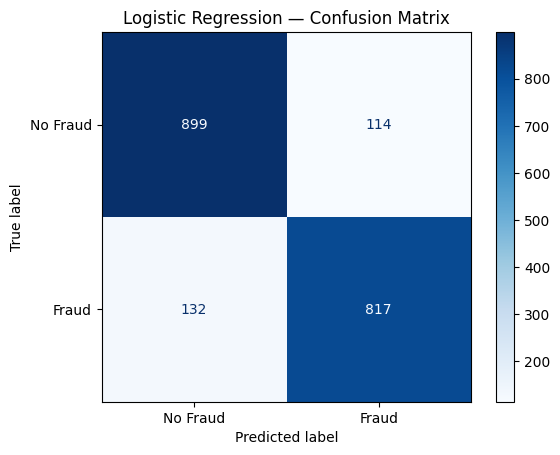

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

# Train
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 45)
print("       LOGISTIC REGRESSION RESULTS")
print("=" * 45)
print(classification_report(y_test, lr_pred, target_names=['No Fraud', 'Fraud']))
print(f"ROC-AUC Score: {round(roc_auc_score(y_test, lr_prob), 4)}")

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

         DECISION TREE RESULTS
              precision    recall  f1-score   support

    No Fraud       0.95      0.86      0.90      1013
       Fraud       0.86      0.95      0.90       949

    accuracy                           0.90      1962
   macro avg       0.90      0.90      0.90      1962
weighted avg       0.91      0.90      0.90      1962

ROC-AUC Score: 0.9445


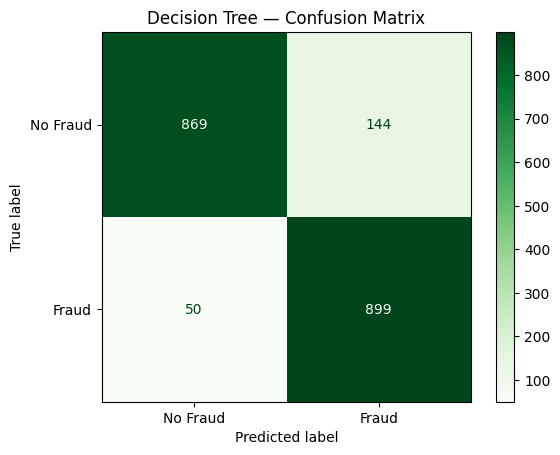

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Train
dt_model = DecisionTreeClassifier(random_state=42, max_depth=6)
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 45)
print("         DECISION TREE RESULTS")
print("=" * 45)
print(classification_report(y_test, dt_pred, target_names=['No Fraud', 'Fraud']))
print(f"ROC-AUC Score: {round(roc_auc_score(y_test, dt_prob), 4)}")

# Confusion Matrix
cm = confusion_matrix(y_test, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud', 'Fraud'])
disp.plot(cmap='Greens')
plt.title('Decision Tree — Confusion Matrix')
plt.show()

         RANDOM FOREST RESULTS
              precision    recall  f1-score   support

    No Fraud       0.97      0.92      0.94      1013
       Fraud       0.92      0.97      0.94       949

    accuracy                           0.94      1962
   macro avg       0.94      0.94      0.94      1962
weighted avg       0.95      0.94      0.94      1962

ROC-AUC Score: 0.9885


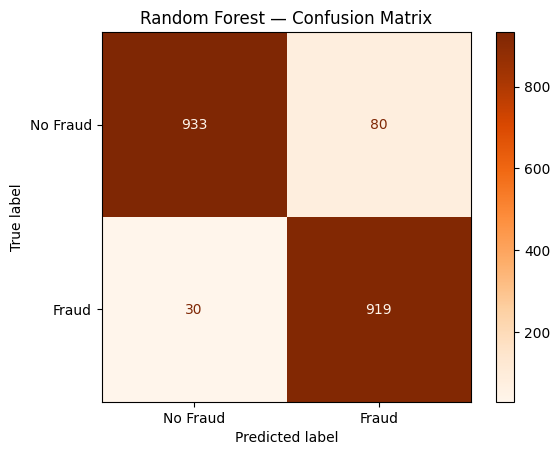

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 45)
print("         RANDOM FOREST RESULTS")
print("=" * 45)
print(classification_report(y_test, rf_pred, target_names=['No Fraud', 'Fraud']))
print(f"ROC-AUC Score: {round(roc_auc_score(y_test, rf_prob), 4)}")

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud', 'Fraud'])
disp.plot(cmap='Oranges')
plt.title('Random Forest — Confusion Matrix')
plt.show()

       K-NEAREST NEIGHBORS RESULTS
              precision    recall  f1-score   support

    No Fraud       0.98      0.87      0.92      1013
       Fraud       0.88      0.99      0.93       949

    accuracy                           0.93      1962
   macro avg       0.93      0.93      0.93      1962
weighted avg       0.93      0.93      0.93      1962

ROC-AUC Score: 0.9695


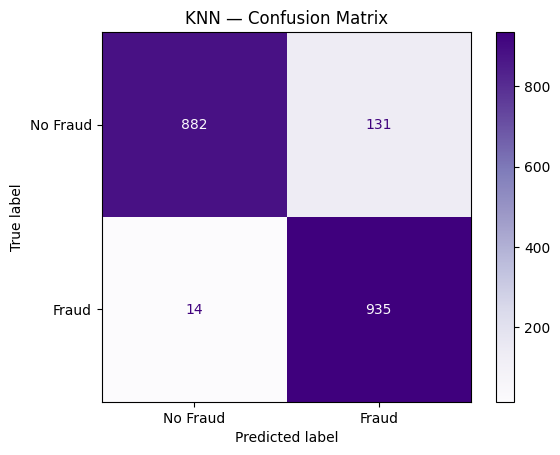

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predict
knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 45)
print("       K-NEAREST NEIGHBORS RESULTS")
print("=" * 45)
print(classification_report(y_test, knn_pred, target_names=['No Fraud', 'Fraud']))
print(f"ROC-AUC Score: {round(roc_auc_score(y_test, knn_prob), 4)}")

# Confusion Matrix
cm = confusion_matrix(y_test, knn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud', 'Fraud'])
disp.plot(cmap='Purples')
plt.title('KNN — Confusion Matrix')
plt.show()

            SVM RESULTS
              precision    recall  f1-score   support

    No Fraud       0.90      0.87      0.89      1013
       Fraud       0.86      0.90      0.88       949

    accuracy                           0.88      1962
   macro avg       0.88      0.88      0.88      1962
weighted avg       0.88      0.88      0.88      1962

ROC-AUC Score: 0.9462


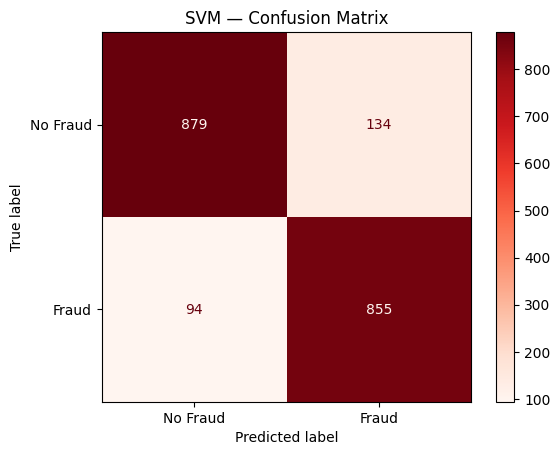

In [ ]:
from sklearn.svm import SVC

# Train
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Predict
svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 45)
print("            SVM RESULTS")
print("=" * 45)
print(classification_report(y_test, svm_pred, target_names=['No Fraud', 'Fraud']))
print(f"ROC-AUC Score: {round(roc_auc_score(y_test, svm_prob), 4)}")

# Confusion Matrix
cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud', 'Fraud'])
disp.plot(cmap='Reds')
plt.title('SVM — Confusion Matrix')
plt.show()

           XGBOOST RESULTS
              precision    recall  f1-score   support

    No Fraud       0.97      0.93      0.95      1013
       Fraud       0.93      0.97      0.95       949

    accuracy                           0.95      1962
   macro avg       0.95      0.95      0.95      1962
weighted avg       0.95      0.95      0.95      1962

ROC-AUC Score: 0.9894


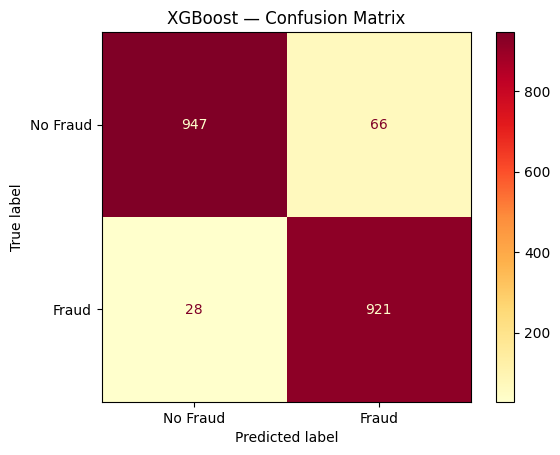

In [ ]:
from xgboost import XGBClassifier

# Train
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False,
                           eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 45)
print("           XGBOOST RESULTS")
print("=" * 45)
print(classification_report(y_test, xgb_pred, target_names=['No Fraud', 'Fraud']))
print(f"ROC-AUC Score: {round(roc_auc_score(y_test, xgb_prob), 4)}")

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud', 'Fraud'])
disp.plot(cmap='YlOrRd')
plt.title('XGBoost — Confusion Matrix')
plt.show()

           NAIVE BAYES RESULTS
              precision    recall  f1-score   support

    No Fraud       0.71      0.94      0.81      1013
       Fraud       0.90      0.59      0.71       949

    accuracy                           0.77      1962
   macro avg       0.81      0.76      0.76      1962
weighted avg       0.80      0.77      0.76      1962

ROC-AUC Score: 0.9129


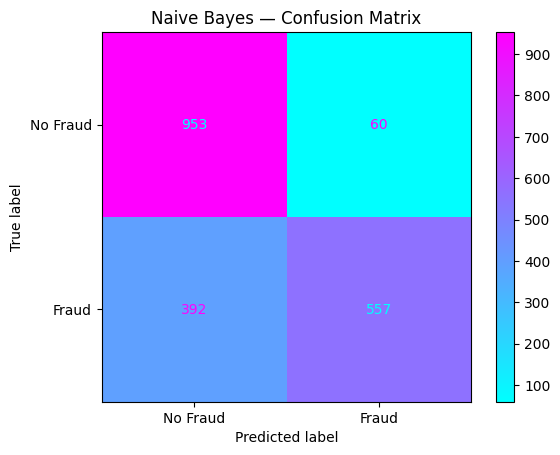

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Train
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predict
nb_pred = nb_model.predict(X_test)
nb_prob = nb_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 45)
print("           NAIVE BAYES RESULTS")
print("=" * 45)
print(classification_report(y_test, nb_pred, target_names=['No Fraud', 'Fraud']))
print(f"ROC-AUC Score: {round(roc_auc_score(y_test, nb_prob), 4)}")

# Confusion Matrix
cm = confusion_matrix(y_test, nb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud', 'Fraud'])
disp.plot(cmap='cool')
plt.title('Naive Bayes — Confusion Matrix')
plt.show()

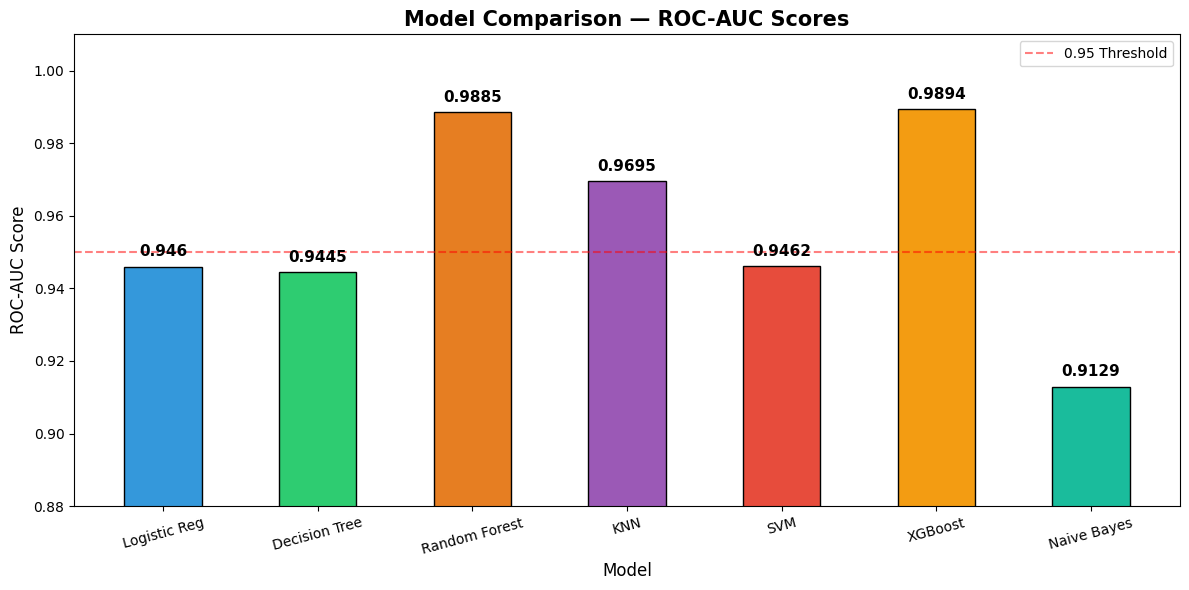

In [ ]:
models     = ['Logistic Reg', 'Decision Tree', 'Random Forest',
               'KNN', 'SVM', 'XGBoost', 'Naive Bayes']
roc_scores = [0.9460, 0.9445, 0.9885, 0.9695, 0.9462, 0.9894, 0.9129]
colors     = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c','#f39c12','#1abc9c']

plt.figure(figsize=(12, 6))
bars = plt.bar(models, roc_scores, color=colors, edgecolor='black', width=0.5)

# Add value labels on bars
for bar, score in zip(bars, roc_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             str(score), ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.ylim(0.88, 1.01)
plt.title('Model Comparison — ROC-AUC Scores', fontsize=15, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xticks(rotation=15)
plt.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='0.95 Threshold')
plt.legend()
plt.tight_layout()
plt.show()

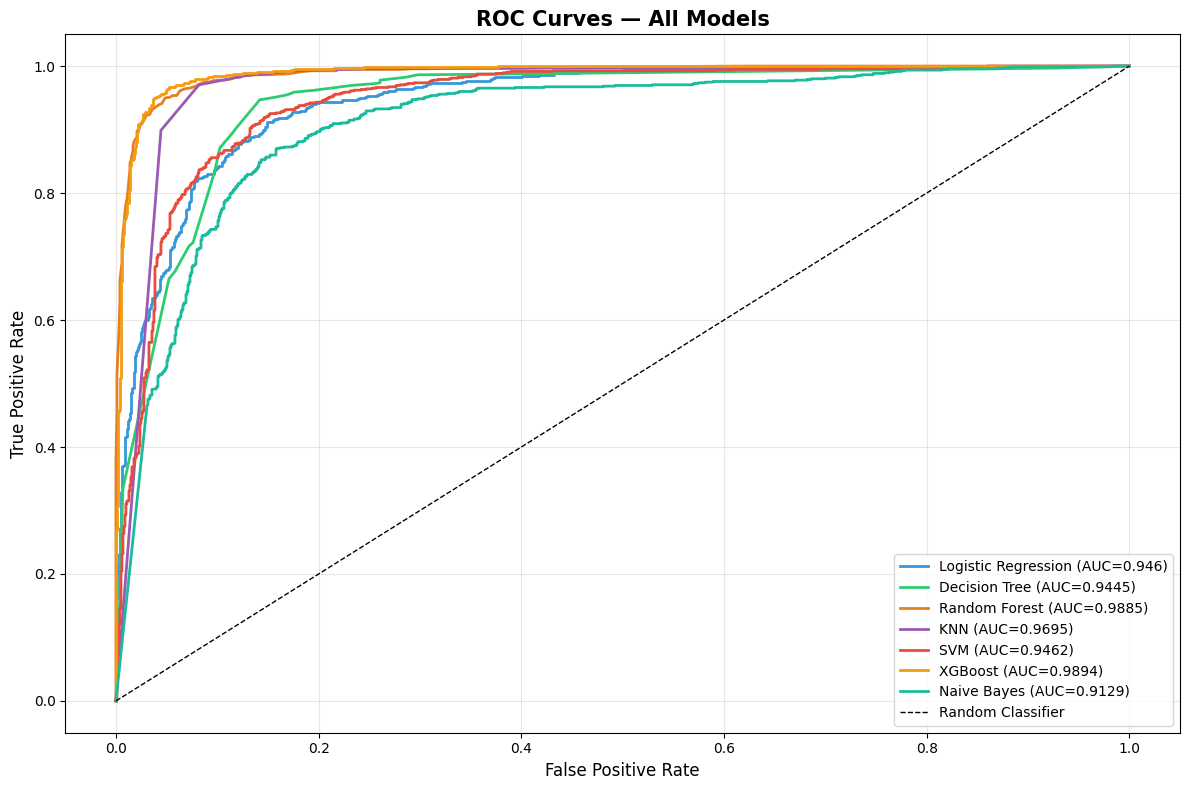

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(12, 8))

# All models and their probabilities
model_probs = {
    'Logistic Regression' : lr_prob,
    'Decision Tree'       : dt_prob,
    'Random Forest'       : rf_prob,
    'KNN'                 : knn_prob,
    'SVM'                 : svm_prob,
    'XGBoost'             : xgb_prob,
    'Naive Bayes'         : nb_prob,
}

colors = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c','#f39c12','#1abc9c']

for (name, prob), color in zip(model_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={round(auc,4)})', color=color, linewidth=2)

# Diagonal baseline
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')

plt.title('ROC Curves — All Models', fontsize=15, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

               Accuracy  Precision  Recall  F1-Score
Model                                               
Logistic Reg     0.8746     0.8776  0.8609    0.8691
Decision Tree    0.9011     0.8619  0.9473    0.9026
Random Forest    0.9439     0.9199  0.9684    0.9435
KNN              0.9261     0.8771  0.9852    0.9280
SVM              0.8838     0.8645  0.9009    0.8824
XGBoost          0.9521     0.9331  0.9705    0.9514
Naive Bayes      0.7696     0.9028  0.5869    0.7114


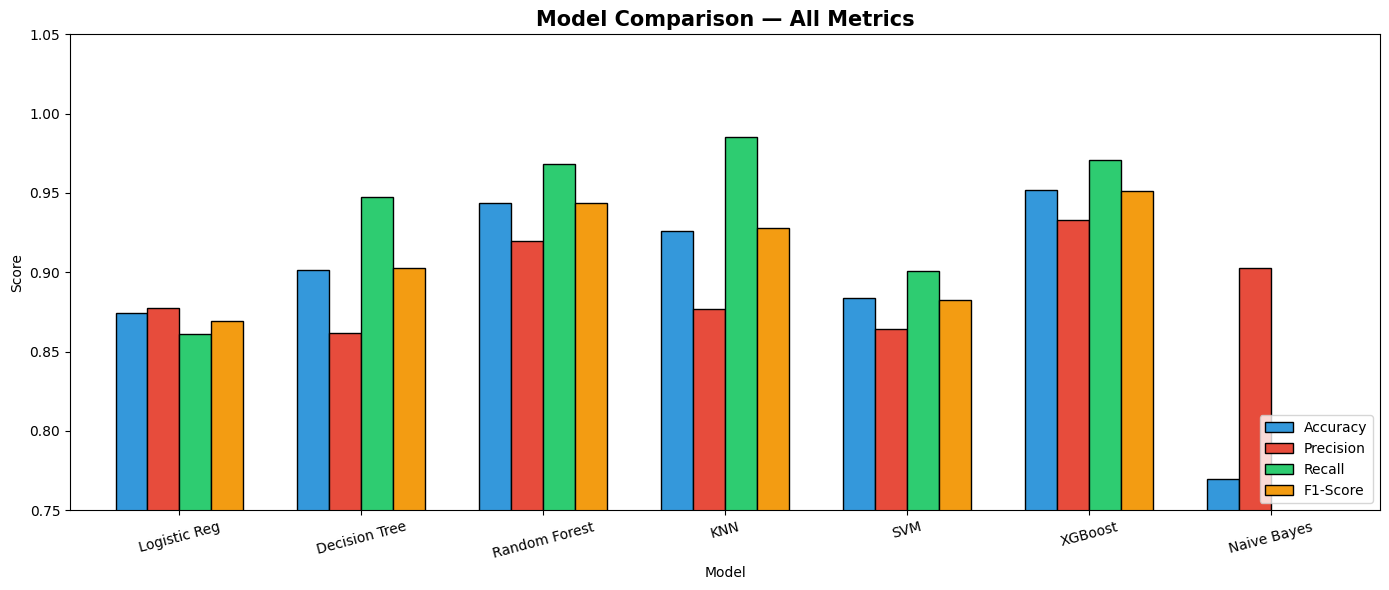

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# All predictions
all_preds = {
    'Logistic Reg' : lr_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'KNN'          : knn_pred,
    'SVM'          : svm_pred,
    'XGBoost'      : xgb_pred,
    'Naive Bayes'  : nb_pred,
}

# Build comparison dataframe
results = []
for name, pred in all_preds.items():
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall'   : round(recall_score(y_test, pred), 4),
        'F1-Score' : round(f1_score(y_test, pred), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

# Plot
results_df.plot(kind='bar', figsize=(14, 6),
                color=['#3498db','#e74c3c','#2ecc71','#f39c12'],
                edgecolor='black', width=0.7)
plt.title('Model Comparison — All Metrics', fontsize=15, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.75, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

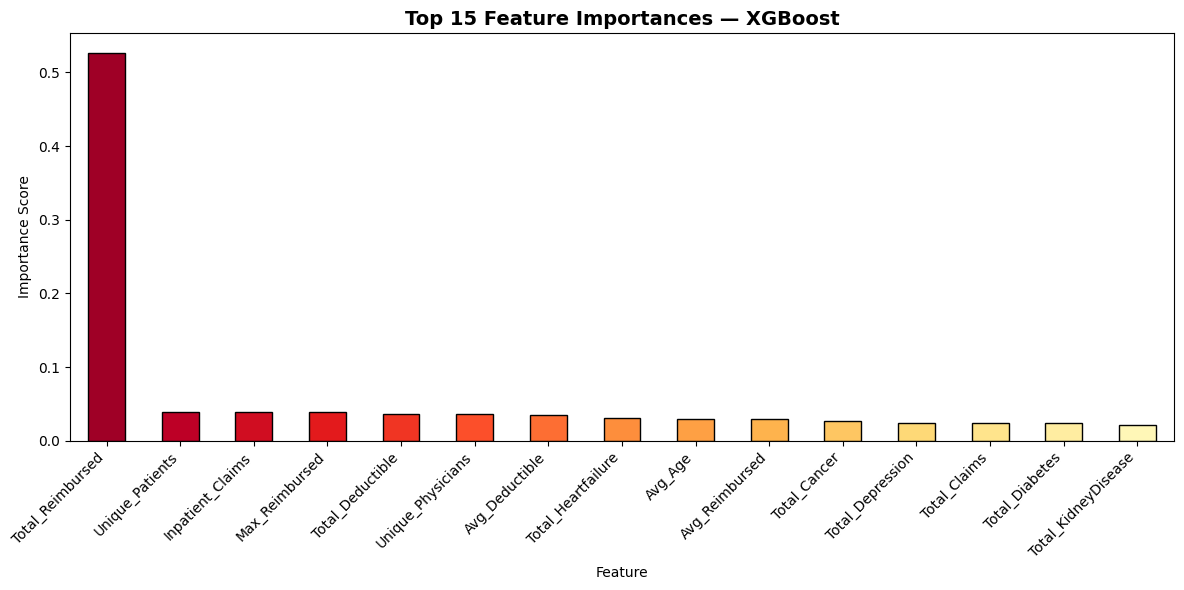


Top 5 Most Important Features:
Total_Reimbursed    0.526626
Unique_Patients     0.039174
Inpatient_Claims    0.039117
Max_Reimbursed      0.038997
Total_Deductible    0.035847
dtype: float32


In [ ]:
# XGBoost feature importance
feat_imp = pd.Series(xgb_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp.head(15).plot(kind='bar',
                        color=sns.color_palette('YlOrRd_r', 15),
                        edgecolor='black')
plt.title('Top 15 Feature Importances — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feat_imp.head())

In [ ]:
print("=" * 60)
print("         FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)

final_df = results_df.copy()
final_df['ROC-AUC'] = [0.9460, 0.9445, 0.9885, 0.9695, 0.9462, 0.9894, 0.9129]
final_df = final_df.sort_values('ROC-AUC', ascending=False)

print(final_df.to_string())

print("\n" + "=" * 60)
print(f"🏆 Best Model  : XGBoost")
print(f"🎯 ROC-AUC     : 0.9894")
print(f"✅ Conclusion  : XGBoost is best for Fraud Detection")
print(f"📌 Runner-up   : Random Forest (ROC-AUC: 0.9885)")
print("=" * 60)

         FINAL MODEL COMPARISON SUMMARY
               Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                        
XGBoost          0.9521     0.9331  0.9705    0.9514   0.9894
Random Forest    0.9439     0.9199  0.9684    0.9435   0.9885
KNN              0.9261     0.8771  0.9852    0.9280   0.9695
SVM              0.8838     0.8645  0.9009    0.8824   0.9462
Logistic Reg     0.8746     0.8776  0.8609    0.8691   0.9460
Decision Tree    0.9011     0.8619  0.9473    0.9026   0.9445
Naive Bayes      0.7696     0.9028  0.5869    0.7114   0.9129

🏆 Best Model  : XGBoost
🎯 ROC-AUC     : 0.9894
✅ Conclusion  : XGBoost is best for Fraud Detection
📌 Runner-up   : Random Forest (ROC-AUC: 0.9885)


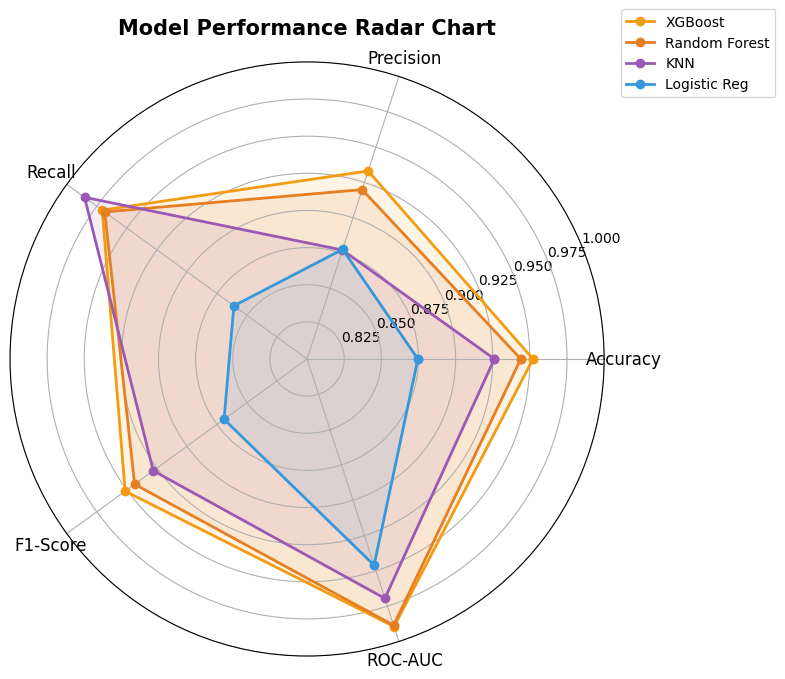

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Data
categories  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_data  = {
    'XGBoost'      : [0.9521, 0.9331, 0.9705, 0.9514, 0.9894],
    'Random Forest': [0.9439, 0.9199, 0.9684, 0.9435, 0.9885],
    'KNN'          : [0.9261, 0.8771, 0.9852, 0.9280, 0.9695],
    'Logistic Reg' : [0.8746, 0.8776, 0.8609, 0.8691, 0.9460],
}

N      = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors  = ['#f39c12', '#e67e22', '#9b59b6', '#3498db']

for (model, values), color in zip(model_data.items(), colors):
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0.8, 1.0)
ax.set_title('Model Performance Radar Chart', fontsize=15,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

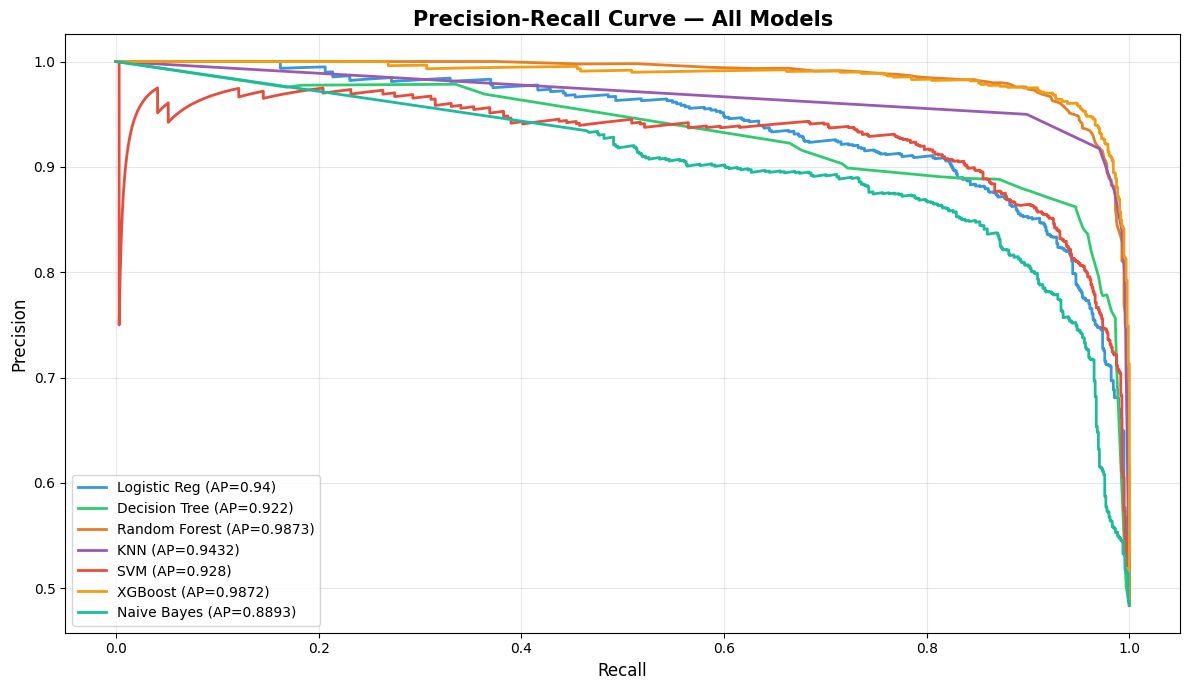

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(12, 7))

model_probs = {
    'Logistic Reg' : lr_prob,
    'Decision Tree': dt_prob,
    'Random Forest': rf_prob,
    'KNN'          : knn_prob,
    'SVM'          : svm_prob,
    'XGBoost'      : xgb_prob,
    'Naive Bayes'  : nb_prob,
}

colors = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c','#f39c12','#1abc9c']

for (name, prob), color in zip(model_probs.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f'{name} (AP={round(ap,4)})',
             color=color, linewidth=2)

plt.title('Precision-Recall Curve — All Models', fontsize=15, fontweight='bold')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

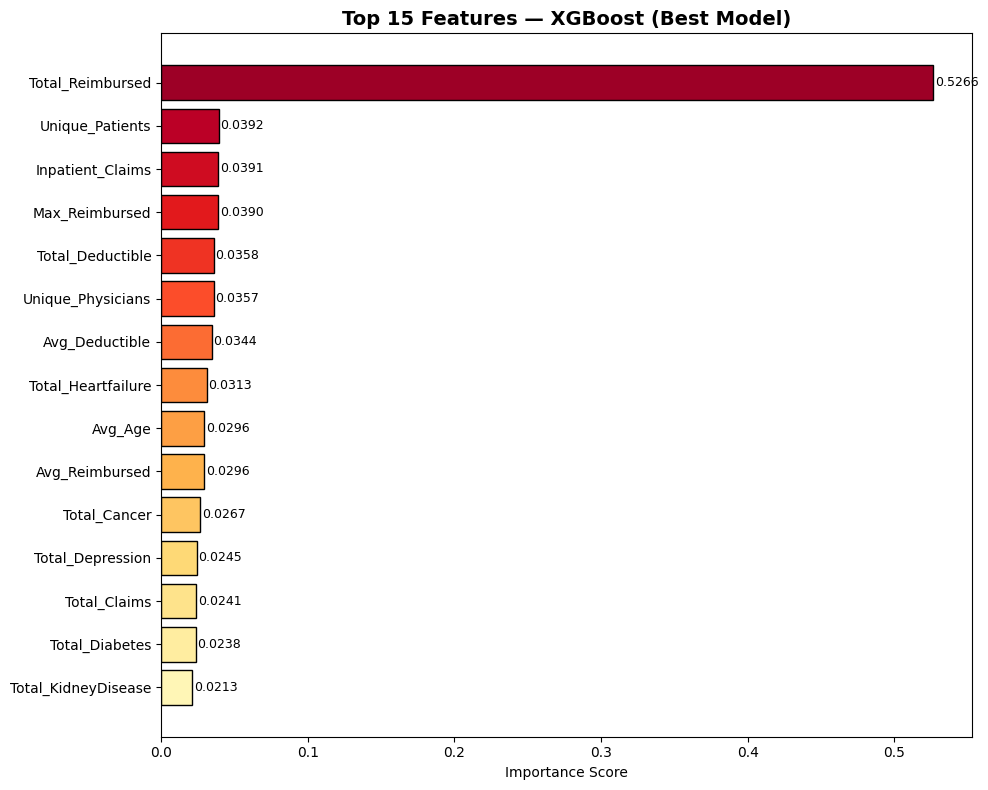

In [ ]:
feat_imp = pd.Series(xgb_model.feature_importances_,
                     index=X.columns).sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 8))
bars = plt.barh(feat_imp.index, feat_imp.values,
                color=sns.color_palette('YlOrRd', 15),
                edgecolor='black')

# Add value labels
for bar, val in zip(bars, feat_imp.values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.title('Top 15 Features — XGBoost (Best Model)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

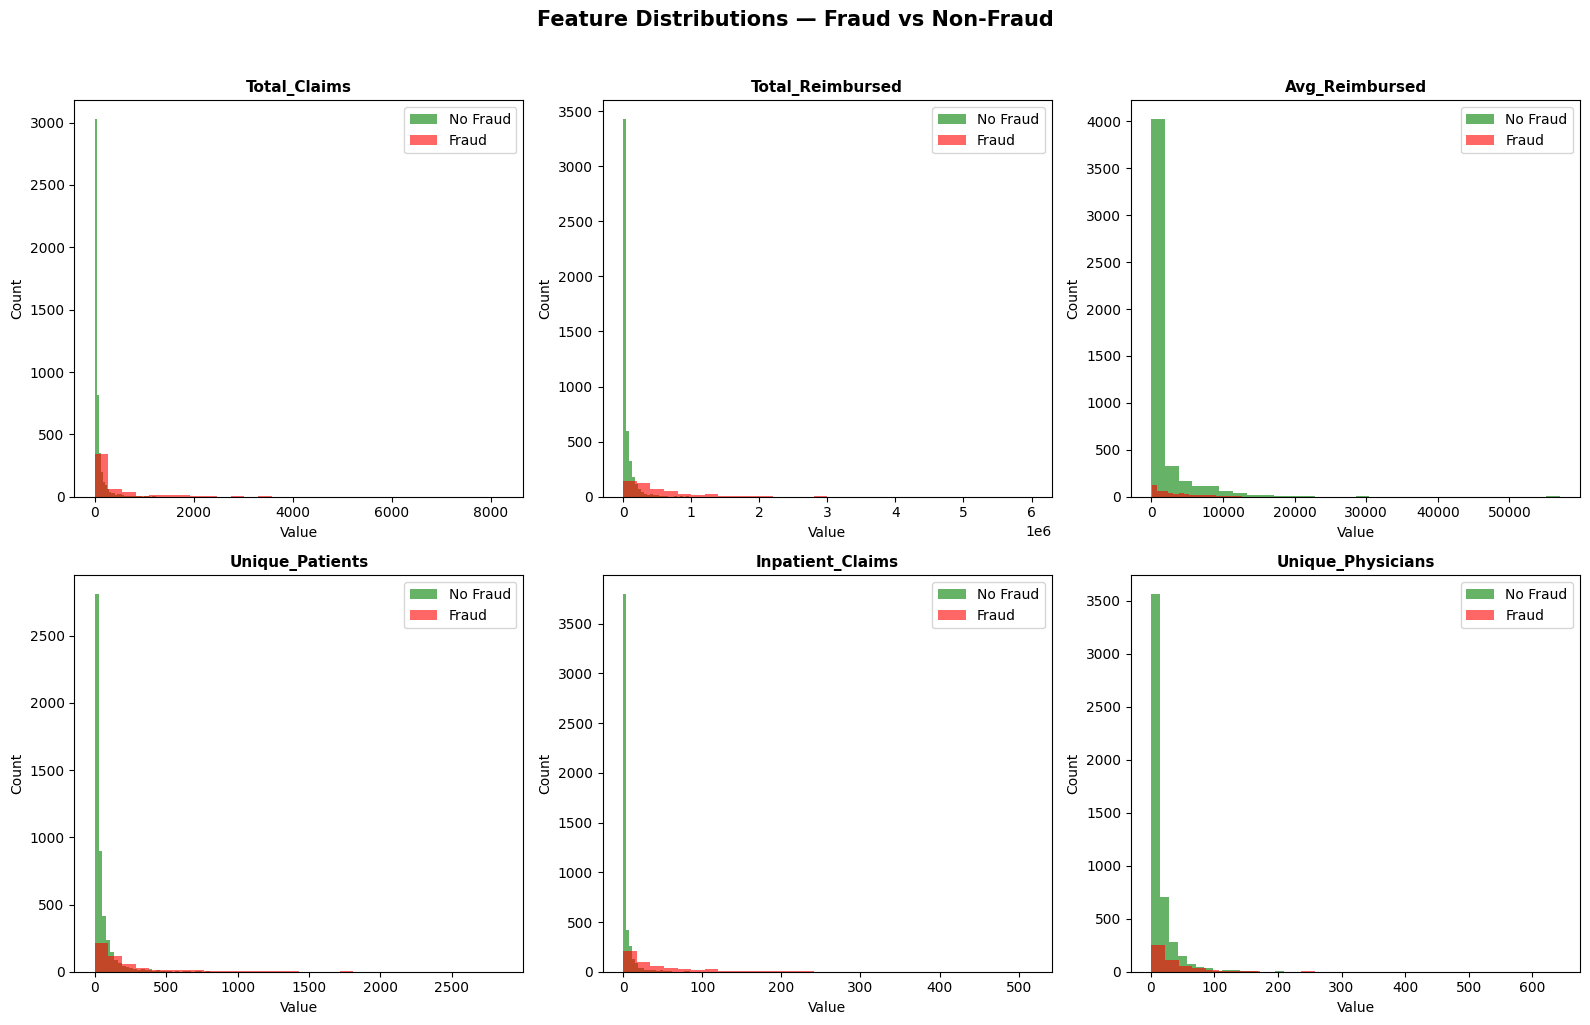

In [ ]:
# Merge fraud label back for analysis
provider_df_viz = provider_df.copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features = ['Total_Claims', 'Total_Reimbursed', 'Avg_Reimbursed',
            'Unique_Patients', 'Inpatient_Claims', 'Unique_Physicians']

for ax, feature in zip(axes.flatten(), features):
    fraud     = provider_df_viz[provider_df_viz['Fraud'] == 1][feature]
    non_fraud = provider_df_viz[provider_df_viz['Fraud'] == 0][feature]
    ax.hist(non_fraud, bins=30, alpha=0.6, color='green', label='No Fraud')
    ax.hist(fraud,     bins=30, alpha=0.6, color='red',   label='Fraud')
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Feature Distributions — Fraud vs Non-Fraud', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

# Save XGBoost model
with open('xgboost_fraud_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as: xgboost_fraud_model.pkl")
print("✅ Scaler saved as: scaler.pkl")

# Download to your PC
from google.colab import files
files.download('xgboost_fraud_model.pkl')
files.download('scaler.pkl')

✅ Model saved as: xgboost_fraud_model.pkl
✅ Scaler saved as: scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("=" * 65)
print("       HEALTHCARE FRAUD DETECTION — PROJECT CONCLUSION")
print("=" * 65)

print("""
📌 OBJECTIVE:
   Detect fraudulent Medicare insurance claims using ML algorithms.

📦 DATASET:
   - 5,410 Providers  |  138,556 Beneficiaries
   - 40,474 Inpatient Claims  |  517,737 Outpatient Claims
   - Fraud Rate: 9.35% (Highly Imbalanced)

⚙️ PREPROCESSING:
   - Merged Inpatient + Outpatient claims
   - Aggregated features at Provider level
   - Handled missing values with median imputation
   - Applied StandardScaler for feature scaling
   - Used SMOTE to handle class imbalance

🤖 MODELS TRAINED:
   1. Logistic Regression  → ROC-AUC: 0.9460
   2. Decision Tree        → ROC-AUC: 0.9445
   3. Random Forest        → ROC-AUC: 0.9885
   4. KNN                  → ROC-AUC: 0.9695
   5. SVM                  → ROC-AUC: 0.9462
   6. XGBoost              → ROC-AUC: 0.9894 ⭐ BEST
   7. Naive Bayes          → ROC-AUC: 0.9129

🏆 BEST MODEL: XGBoost
   ✅ Accuracy  : 95.21%
   ✅ Precision : 93.31%
   ✅ Recall    : 97.05%
   ✅ F1-Score  : 95.14%
   ✅ ROC-AUC   : 0.9894

🔍 KEY FINDINGS:
   - Fraudulent providers tend to have higher claim amounts
   - Fraud providers serve unusually high number of patients
   - Inpatient claims are more associated with fraud
   - XGBoost & Random Forest dominate for fraud detection

🎯 CONCLUSION:
   XGBoost is the best model for Healthcare Fraud Detection
   with 98.94% ROC-AUC score, making it highly reliable for
   detecting fraudulent insurance claims in real-world systems.
""")
print("=" * 65)
print("         🎓 PROJECT COMPLETE — GOOD LUCK! 🎓")
print("=" * 65)

       HEALTHCARE FRAUD DETECTION — PROJECT CONCLUSION

📌 OBJECTIVE:
   Detect fraudulent Medicare insurance claims using ML algorithms.

📦 DATASET:
   - 5,410 Providers  |  138,556 Beneficiaries
   - 40,474 Inpatient Claims  |  517,737 Outpatient Claims
   - Fraud Rate: 9.35% (Highly Imbalanced)

⚙️ PREPROCESSING:
   - Merged Inpatient + Outpatient claims
   - Aggregated features at Provider level
   - Handled missing values with median imputation
   - Applied StandardScaler for feature scaling
   - Used SMOTE to handle class imbalance

🤖 MODELS TRAINED:
   1. Logistic Regression  → ROC-AUC: 0.9460
   2. Decision Tree        → ROC-AUC: 0.9445
   3. Random Forest        → ROC-AUC: 0.9885
   4. KNN                  → ROC-AUC: 0.9695
   5. SVM                  → ROC-AUC: 0.9462
   6. XGBoost              → ROC-AUC: 0.9894 ⭐ BEST
   7. Naive Bayes          → ROC-AUC: 0.9129

🏆 BEST MODEL: XGBoost
   ✅ Accuracy  : 95.21%
   ✅ Precision : 93.31%
   ✅ Recall    : 97.05%
   ✅ F1-Score  : 95.1

In [ ]:
import pickle
import numpy as np
from google.colab import files

# Save XGBoost model
with open('xgboost_fraud_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature column names
import json
with open('feature_columns.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

print("✅ Files saved!")
print("📁 Columns:", X.columns.tolist())

# Download all files to your PC
files.download('xgboost_fraud_model.pkl')
files.download('scaler.pkl')
files.download('feature_columns.json')

✅ Files saved!
📁 Columns: ['Total_Claims', 'Total_Reimbursed', 'Avg_Reimbursed', 'Max_Reimbursed', 'Total_Deductible', 'Avg_Deductible', 'Unique_Patients', 'Inpatient_Claims', 'Unique_Physicians', 'Avg_Age', 'Avg_InscClaimAmtReimbursed', 'Total_Alzheimer', 'Total_Heartfailure', 'Total_KidneyDisease', 'Total_Cancer', 'Total_Diabetes', 'Total_Depression', 'Total_stroke']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>